# 6. Inversion with Waveform Convolution

This notebook extends the inversion examples from notebook 5 by using **waveform-convolved data** throughout.

A TEM system never measures the ideal step-off response: the transmitter current ramps off over a finite time (typically tens to hundreds of microseconds), which **smears the early-time signal**.  Using a step-off forward model when inverting ramp-convolved data introduces a systematic bias that can propagate into the recovered resistivity model.

Topics covered:
1. **Benchmark model** — 3-layer synthetic, three square-loop configurations.
2. **Synthetic convolved data** — step-off response convolved with a linear ramp waveform.
3. **Inversion** — pure waveform inversion vs circle warm-start.
4. **Recovery plots** — model recovery comparison.


In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sys.path.insert(0, r'C:\Users\pamcl\OneDrive - Danmarks Tekniske Universitet\Dokumenter\Projects\Python\pyTEM')

from pytem import (
    fwd_circle_central,
    fwd_circle_offset,
    fwd_square_central,
    fwd_square_offset,
    getJ_ana,
    getJ_fd,
    getR,
    getRMS,
    invert,
    butterworth_filter,
    cascade_filter,
    convolve_waveform,
    plot_sounding,
    plot_model,
    plot_inversion,
    MU0,
    HAS_NUMBA,
    HAS_CUDA,
    HANKEL_FILTERS,
    FOURIER_FILTERS,
    EULER_PARAMS,
)

print(f'Numba: {HAS_NUMBA},  CUDA: {HAS_CUDA}')

Numba: True,  CUDA: True


## 1. Benchmark Model

The same 3-layer synthetic model as notebook 5 is used:

| Layer | Resistivity | Thickness |
|-------|------------|-----------|
| Resistive overburden | 100 Ohm.m | 20 m |
| Conductive target | 10 Ohm.m | 40 m |
| Resistive basement | 500 Ohm.m | half-space |

Three square-loop configurations are modelled; each has a **linear current ramp-off** of duration $T_\text{ramp}$:

| Configuration | $T_\text{ramp}$ |
|---|---|
| 200×200 m central | 0.4 ms |
| 50×50 m central   | 0.2 ms |
| 3×3 m offset      | 0.08 ms |


In [2]:
# --- True model ---
rho_true    = np.array([100.0, 10.0, 500.0])   # [Ohm.m]
thick_true  = np.array([20.0, 40.0])           # [m]  (2 layers -> 2 thicknesses)

# --- Survey geometry ---
tx_radius   = np.sqrt(40.**2 / np.pi)           # equivalent circular radius for 40 m loop
side_length = 40.0                              # square loop side [m]
rx_offset   = 10.0                              # offset receiver distance [m]

print(f'tx_radius = {tx_radius:.2f} m')
print(f'rho_true  = {rho_true}')
print(f'thick_true = {thick_true}')


tx_radius = 22.57 m
rho_true  = [100.  10. 500.]
thick_true = [20. 40.]


## 2. Waveform Definition and Synthetic Data

The waveform is a **single linear ramp-off**: the transmitter current drops from 1 A to 0 A over $T_\text{ramp}$ seconds starting at $t = 0$.

$$I(t) = \begin{cases} 1 & t < 0 \\ 1 - t / T_\text{ramp} & 0 \le t \le T_\text{ramp} \\ 0 & t > T_\text{ramp} \end{cases}$$

For each configuration:
1. Compute the step-off response on a dense log-spaced time grid.
2. Convolve with the waveform using `convolve_waveform` to produce the "measured" data.
3. Add Gaussian noise (2 % fractional, with a noise floor $\propto t^{-0.5}$).


In [ ]:
import time

rng = np.random.default_rng(42)

# --- Config specs ---
config_specs = [
    ('200×200 m central', 200.0, 'square_central', None, 5,
     np.logspace(-5, -2, 31), 0.02, 1e-13),
    ('50×50 m central',   50.0,  'square_central', None, 5,
     np.logspace(-5, -2, 31), 0.02, 1e-13),
    ('3×3 m offset',       3.0,  'square_offset',  10.0, 11,
     np.logspace(-5, -2, 31), 0.02, 1e-13),
]

# --- Waveform: linear ramp-off, t in [0, T_ramp] ---
waveform_ramp = {
    '200×200 m central': 0.4e-3,   # 400 µs — large loop
    '50×50 m central':   0.2e-3,   # 200 µs
    '3×3 m offset':      0.08e-3,  # 80 µs  — small loop
}

_fwd_kw = dict(transform='dlf', hankel_filter='key_101', fourier_filter='key_81')
N_STEP   = 300   # dense grid for step-response (data generation and plotting only)

t0_timer = time.perf_counter()
configs  = {}

for spec in config_specs:
    label, L, geom_sq, rx, nq, times_all, noise_frac, noise_floor_amp = spec

    T_ramp = waveform_ramp[label]
    wf_t   = np.array([0.0, T_ramp])   # ramp from t=0 to t=T_ramp
    wf_I   = np.array([1.0, 0.0])      # current 1 A → 0 A

    # Dense step-response grid spanning gate window
    step_t = np.logspace(
        np.log10(times_all.min() * 1e-2),
        np.log10(times_all.max() * 10.0),
        N_STEP,
    )

    # Step-off response at dense times
    if rx is None:
        step_resp = -fwd_square_central(thick_true, rho_true, L, step_t,
                                        n_quad=nq, **_fwd_kw)
    else:
        step_resp = -fwd_square_offset(thick_true, rho_true, L, rx, 0.0,
                                       step_t, n_quad=nq, **_fwd_kw)

    # Convolve with waveform at ALL gates (used for plotting only)
    d_clean_all = convolve_waveform(step_t, step_resp, wf_t, wf_I, times_all)

    # ---------------------------------------------------------------
    # INVERSION GATE FILTER: post-ramp AND sufficient signal-to-noise.
    #
    # Two criteria must both be met:
    #
    # 1. t > T_ramp: the ramp has fully turned off, so the convolution
    #    integral covers the full [0, T_ramp] window.
    #
    # 2. SNR: the true convolved signal must exceed the noise floor.
    #    The noise model is  noise = max(noise_frac * |d|, noise_floor(t)).
    #    When |d_clean| < noise_floor / noise_frac the absolute noise floor
    #    dominates and noise_log = noise/|d_obs| ≈ 1 (100 % noise).
    #    In log-space the residual log(d_obs) - log(d_pred) is then huge
    #    (d_obs = random sign at noise floor, d_pred ≈ 0 from physics),
    #    driving the RMS up to 3+ regardless of model quality.
    #    Excluding these gates costs no information — there is no signal.
    # ---------------------------------------------------------------
    noise_floor_t = noise_floor_amp * times_all ** (-0.5)
    snr_ok  = np.abs(d_clean_all) > noise_floor_t / noise_frac   # signal > noise floor
    mask    = (times_all > T_ramp) & snr_ok
    times_inv = times_all[mask]
    d_clean   = d_clean_all[mask]

    L_circ      = L / np.sqrt(np.pi)
    noise_floor = noise_floor_amp * times_inv ** (-0.5)
    noise_std   = np.maximum(noise_frac * np.abs(d_clean), noise_floor)
    d_obs       = d_clean + noise_std * rng.standard_normal(len(d_clean))

    print(f'{label}: T_ramp={T_ramp*1e3:.2f} ms  '
          f'{len(times_inv)}/{len(times_all)} gates (post-ramp + SNR>1)  '
          f'noise={noise_frac*100:.0f}%')

    configs[label] = dict(
        L=L, L_circ=L_circ,
        geom_sq=geom_sq, rx=rx, n_quad=nq,
        wf_t=wf_t, wf_I=wf_I, T_ramp=T_ramp,
        times_all=times_all,    d_clean_all=d_clean_all,  # full curve for plots
        times_inv=times_inv,    d_clean=d_clean,          # inversion subset
        d_obs_inv=d_obs,        noise_std_inv=noise_std,
    )

print(f'\n3 configs built in {time.perf_counter()-t0_timer:.2f} s')

# --- Plot convolved data; mark the inversion subset ---
fig, ax = plt.subplots(figsize=(5, 4))
for (label, cfg), c in zip(configs.items(), ['C0', 'C1', 'C2']):
    ax.loglog(cfg['times_all'], np.abs(cfg['d_clean_all']), '-',  color=c, lw=1.2, alpha=0.4)
    ax.loglog(cfg['times_inv'], np.abs(cfg['d_obs_inv']),   'o',  color=c, ms=4, label=label)
ax.set_xlabel('Time [s]')
ax.set_ylabel(r'$-dB_z/dt$ (convolved) [V/m²]')
ax.legend()
ax.grid(True, which='both', alpha=0.5)
fig.tight_layout()
plt.show()


## 3. Inversion: Pure Waveform vs Circle Warm-start

Each convolved dataset is inverted **twice** using the same starting model and inversion settings:

1. **Pure waveform inversion** — `invert()` with `waveform_times` and `waveform_currents`.  
   The square forward model is used throughout every Gauss-Newton iteration.

2. **Circle warm-start** — `invert()` with `circle_warmstart=True`.  
   The inversion runs with the cheaper equivalent-area circle model until convergence, then a final refinement step is taken with the exact square forward model.  
   This typically gives an identical result at a fraction of the compute time.


In [ ]:
import time

n_layers   = 15
depths_inv = np.geomspace(2.0, 200.0, n_layers)
thick_inv  = np.append(np.diff(depths_inv), depths_inv[-1])

rho_start  = np.ones(n_layers) * 100.0
lrho_start = np.log(rho_start)

results_wf = {}
results_ws = {}
timings    = {}

for label, cfg in configs.items():
    rx_kw = dict(rx_offset=cfg['rx']) if cfg['rx'] is not None else {}
    timings[label] = {}
    common_kw = dict(
        thicknesses=thick_inv, log_resistivities=lrho_start,
        times=cfg['times_inv'], obs_data=cfg['d_obs_inv'],
        noise_std=cfg['noise_std_inv'], max_noise_frac=0.0,
        alpha_start=None, alpha_steps=20, alpha_step=1/9, maxit=20,
        transform='euler', hankel_filter='key_101', fourier_filter='key_81',
        use_numba=HAS_NUMBA, use_cuda=HAS_CUDA,
        calc_sens=False, analytical_j=True,
        tx_radius=cfg['L'], geometry=cfg['geom_sq'], n_quad=cfg['n_quad'],
        waveform_times=cfg['wf_t'], waveform_currents=cfg['wf_I'],
        waveform_n_quad=5, **rx_kw,
    )

    print(f'[Pure]       {label} ...')
    t0 = time.perf_counter()
    results_wf[label] = invert(**common_kw)
    timings[label]['wf'] = time.perf_counter() - t0
    print(f"  RMS = {results_wf[label]['rms_history'][-1]:.4f}  ({timings[label]['wf']:.1f} s)\n")

    print(f'[Warm-start] {label} ...')
    t0 = time.perf_counter()
    results_ws[label] = invert(circle_warmstart=True, **common_kw)
    timings[label]['ws'] = time.perf_counter() - t0
    print(f"  RMS = {results_ws[label]['rms_history'][-1]:.4f}  ({timings[label]['ws']:.1f} s)\n")

print(f"\n{'Config':<22}  {'Pure WF':>13}  {'Warm-start':>13}  {'Speedup':>9}")
print('-' * 66)
for label in configs:
    rms_wf = results_wf[label]['rms_history'][-1]
    rms_ws = results_ws[label]['rms_history'][-1]
    t_wf = timings[label]['wf']
    t_ws = timings[label]['ws']
    print(f"{label:<22}  {t_wf:>7.1f} s  {rms_wf:>5.3f}  {t_ws:>7.1f} s  {rms_ws:>5.3f}  {t_wf/t_ws:>8.1f}×")


[Pure]       200×200 m central ...
Building initial Jacobian...
  done (3.0 s)
alpha_start = 1.34e+04
Iteration   1:  RMS = 76.7677
    alpha = 13443.352,  RMS = 48.3191
    alpha = 10408.699,  RMS = 50.0955
    RMS increased — stopping alpha search early.
Iteration   2:  RMS = 48.3191
    alpha = 17362.757,  RMS = 12.6791
    alpha = 13443.352,  RMS = 12.7343
    RMS increased — stopping alpha search early.
Iteration   3:  RMS = 12.6791
    alpha = 22424.863,  RMS = 5.2239
    alpha = 17362.757,  RMS = 4.9109
    alpha = 13443.352,  RMS = 4.7500
    alpha = 10408.699,  RMS = 4.6803
    alpha = 8059.078,  RMS = 4.6613
    alpha = 6239.851,  RMS = 4.6673
    RMS increased — stopping alpha search early.
Iteration   4:  RMS = 4.6613
    alpha = 10408.699,  RMS = 4.5191
    alpha = 8059.078,  RMS = 4.3362
    alpha = 6239.851,  RMS = 4.1934
    alpha = 4831.290,  RMS = 4.0728
    alpha = 3740.693,  RMS = 3.9619
    alpha = 2896.282,  RMS = 3.8575
    alpha = 2242.486,  RMS = 3.7585
    alp

## 4. Recovery: Model Comparison

The figure below shows, for each configuration, the recovered resistivity profiles for:

- **Pure waveform inversion** — full square forward model used throughout all Gauss-Newton iterations.
- **Circle warm-start** — inversion runs with the cheaper equivalent-circle model, then one refinement step with the exact square model.

The dashed black line shows the true model.


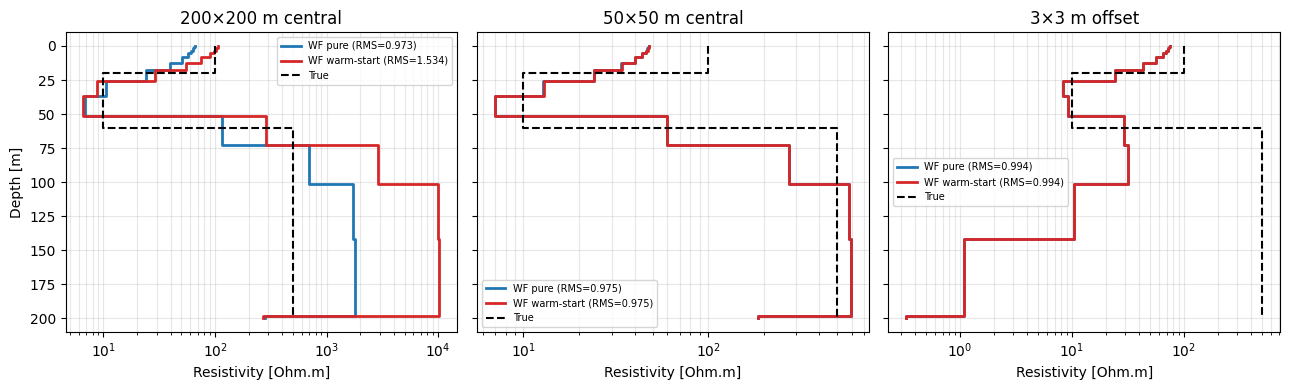

In [ ]:
# True model step function for plotting
deps_t = np.concatenate(([0], np.cumsum(thick_true), [depths_inv[-1]]))
rho_t  = np.concatenate([np.repeat(rho_true[:-1], 2), [rho_true[-1], rho_true[-1]]])
dep_t  = np.repeat(deps_t, 2)[1:-1]

fig, axs = plt.subplots(1, len(configs), figsize=(13, 4), sharey=True)

for j, (label, cfg) in enumerate(configs.items()):
    res_pure = results_wf[label]
    res_ws_  = results_ws[label]

    thick_r  = res_pure['thicknesses'][:-1]
    depths_r = np.concatenate(([0], np.cumsum(thick_r)))

    ax = axs[j] if len(configs) > 1 else axs

    for res, color, tag in [
        (res_pure, 'C0', f"WF pure (RMS={res_pure['rms_history'][-1]:.3f})"),
        (res_ws_,  'C3', f"WF warm-start (RMS={res_ws_['rms_history'][-1]:.3f})"),
    ]:
        rho_inv  = res['resistivities']
        rho_step = np.repeat(rho_inv, 2)
        dep_step = np.repeat(np.append(depths_r, depths_inv[-1]), 2)[1:-1]
        ax.semilogx(rho_step, dep_step, '-', lw=2, color=color, label=tag)

    ax.semilogx(rho_t, dep_t, '--', lw=1.5, color='k', label='True')
    ax.set_title(label)
    ax.set_xlabel('Resistivity [Ohm.m]')
    ax.invert_yaxis()
    ax.legend(fontsize=7)
    ax.grid(True, which='both', alpha=0.3)

axs[0].set_ylabel('Depth [m]')
fig.tight_layout()
plt.show()
